# OBV Divergence Exit Factor Analysis

## Research Objective
This notebook evaluates the predictive value, stability, and practical usefulness of the **OBV divergence exit factor** inside the Dynamic Mean Reversion & Multi-Factor Flow Alpha framework. The focus is whether an OBV breakout unconfirmed by price provides a reliable warning that a rebound is weakening and that forward return quality is likely to deteriorate.

## Factor Definition
- Use the latest **10 trading days** of close and volume data
- Build **OBV** from daily signed volume accumulation
- Trigger the exit-style signal when:
  - latest **OBV > prior 5-day OBV high**
  - latest **price <= prior 5-day price high**
- Define the raw factor as **latest OBV - prior 5-day OBV high**

## Research Hypothesis
The working hypothesis is that if volume strength pushes OBV to a new short-term high while price fails to confirm with its own breakout, the rebound may be losing quality and becoming more vulnerable to reversal. If the hypothesis holds, stocks with this divergence signal should deliver weaker next-period returns than stocks without the signal.

## Data and Test Design
The factor is tested on the strategy's fixed 33-stock pool over **2016-01-01 to 2026-04-29**, using monthly cross-sectional snapshots aligned with the reference factor notebooks. The analysis includes rank IC, signal-versus-non-signal return comparison, rolling spread inspection, sample-count tracking, annual spread analysis, regression inspection, and heatmap attribution.

Initiating OBV Divergence Factor Diagnostic...
Processing Snapshot: 2026-03-31
Data collection complete.


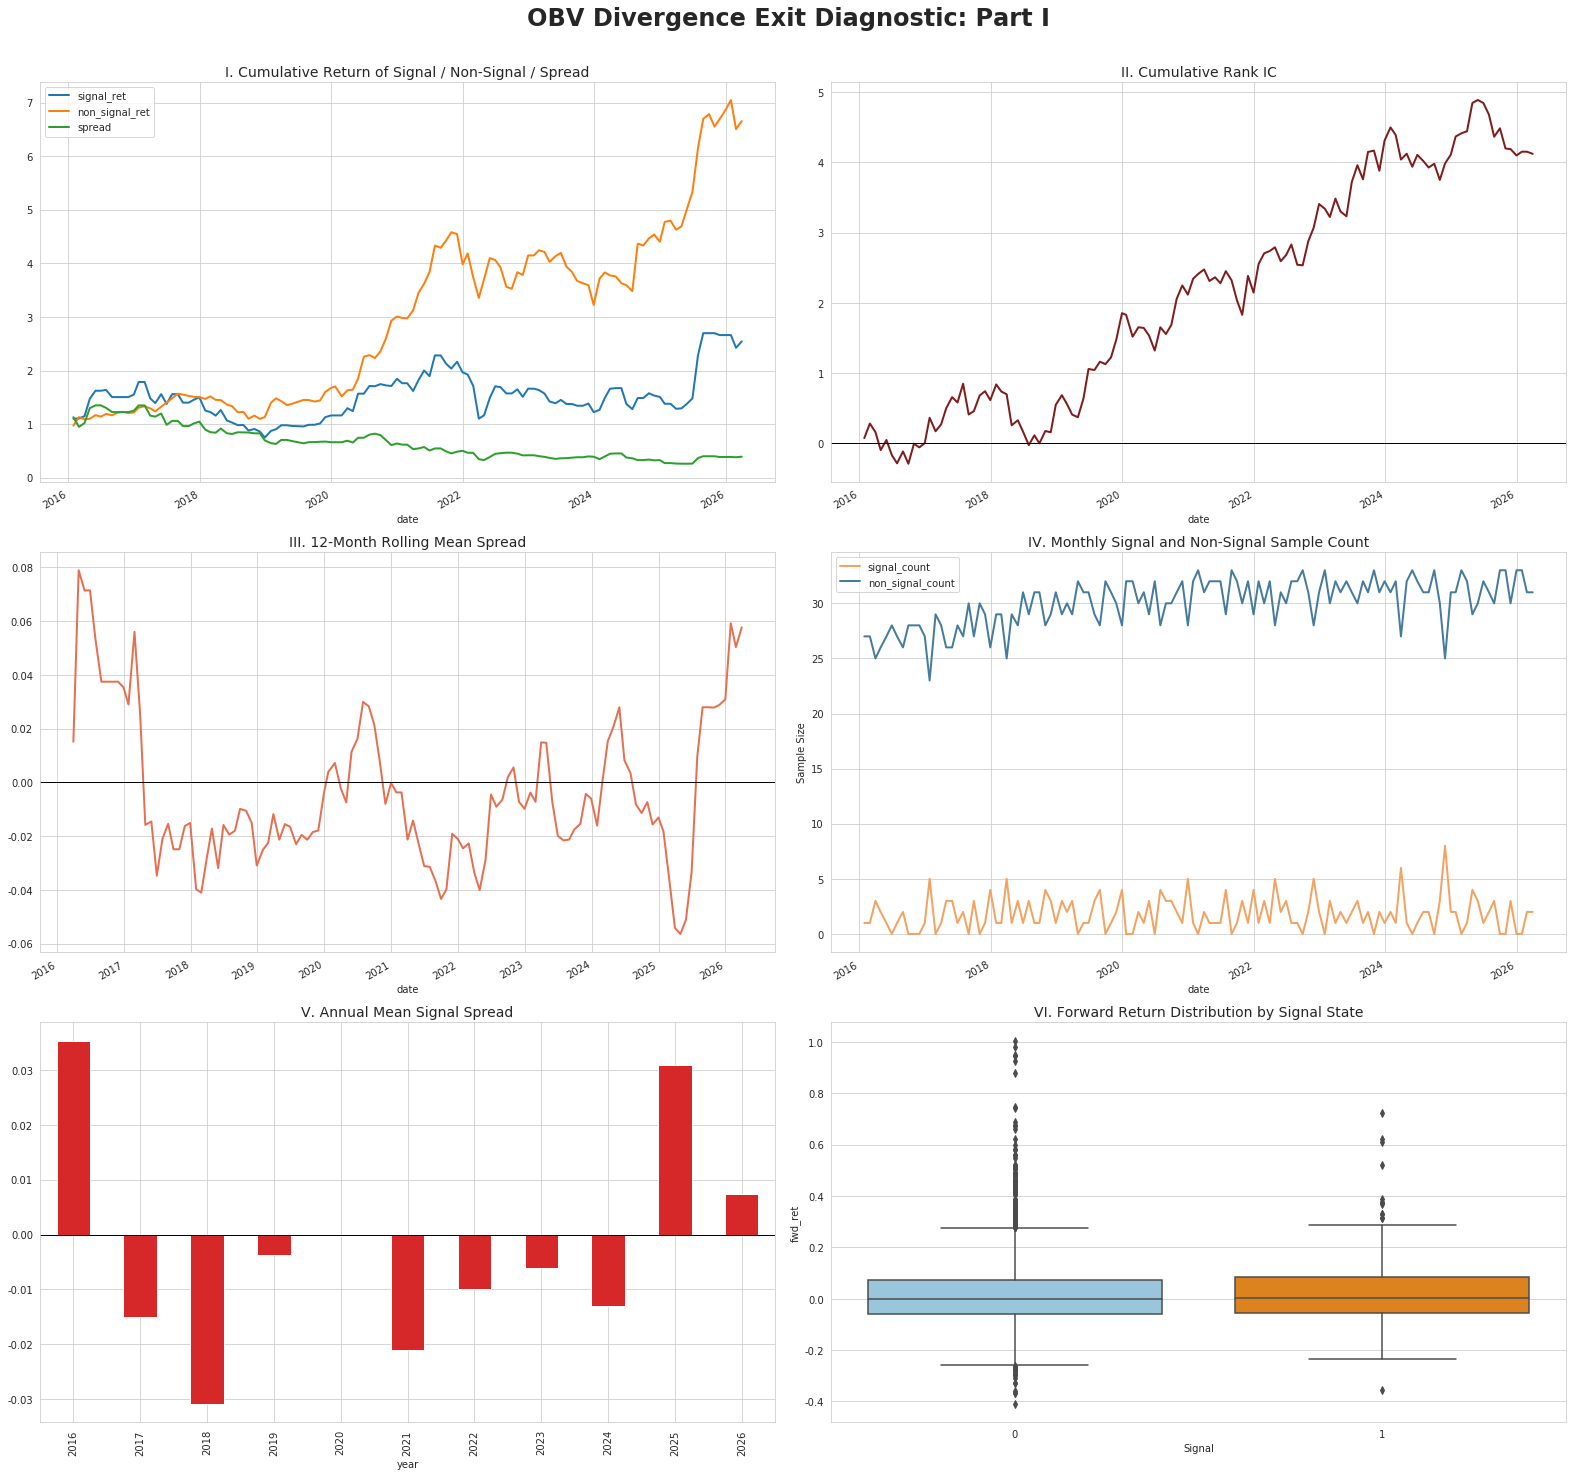

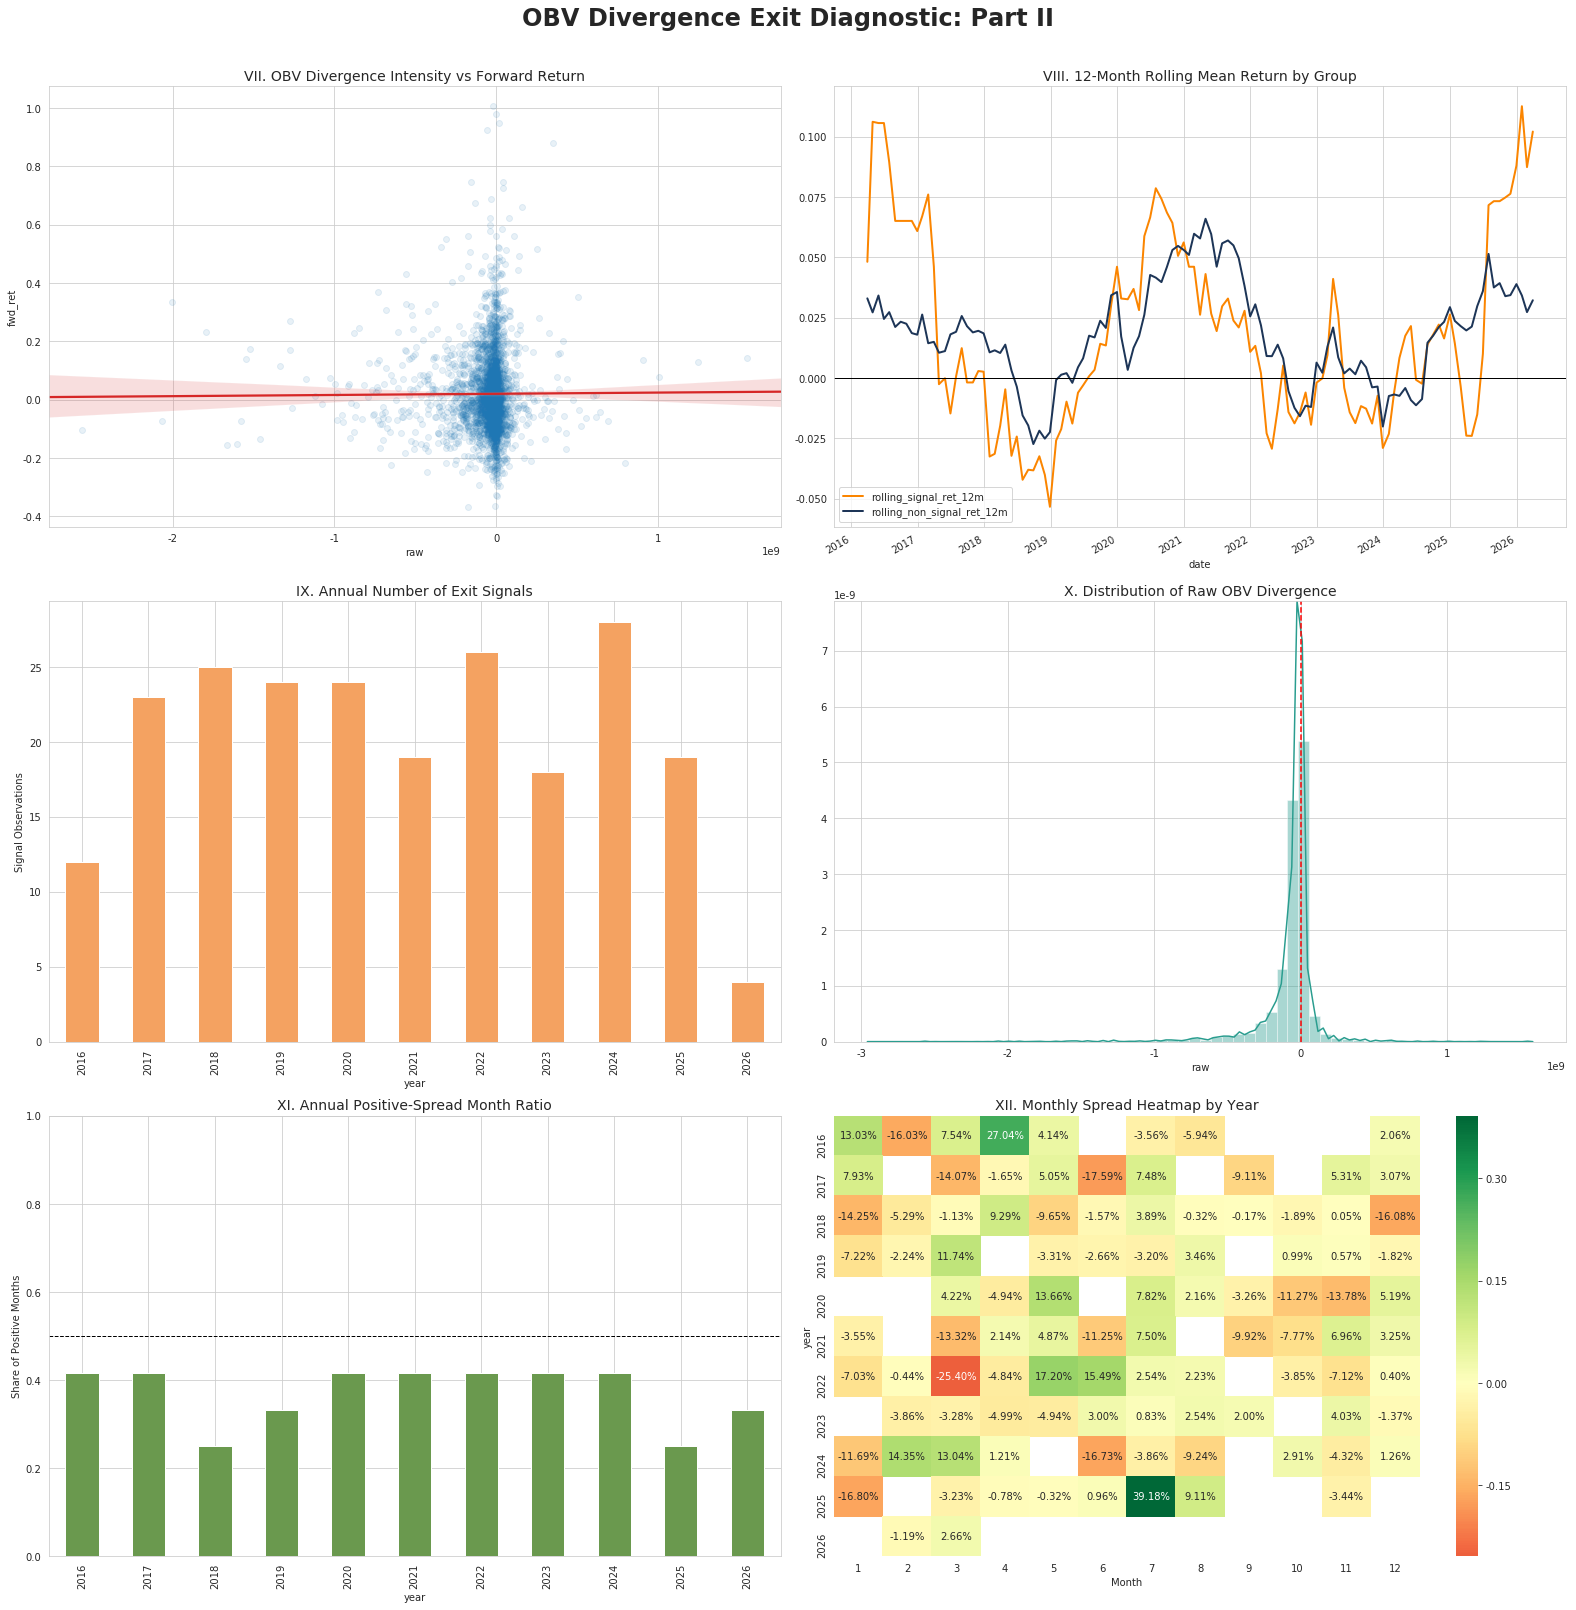


FINAL SUMMARY: OBV DIVERGENCE EXIT FACTOR
------------------------------------------------------------------------------------------
Average Rank IC: 0.0335
ICIR: 0.1597
Signal Mean Return: 1.58%
Non-Signal Mean Return: 1.77%
Signal Spread Mean Return: -0.52%


In [1]:
'''
This diagnostic evaluates the "OBV Divergence Exit" factor used by the
Dynamic Mean Reversion & Multi-Factor Flow Alpha strategy.

Core Logic:
1. Compute OBV from the latest 10 trading days.
2. Trigger a signal when the latest OBV breaks above its prior 5-day high
   while price fails to break above its own prior 5-day high.
3. As an exit-oriented condition, the research checks whether the signal
   precedes weaker forward returns than the non-signal group.
'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from jqdata import *
from scipy.stats import spearmanr
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

STOCK_POOL = [
    '601117.XSHG', '601600.XSHG', '601888.XSHG', '300274.XSHE', '300750.XSHE',
    '601919.XSHG', '002049.XSHE', '603881.XSHG', '002335.XSHE', '600089.XSHG',
    '002236.XSHE', '002056.XSHE', '300866.XSHE', '002611.XSHE', '600760.XSHG',
    '300693.XSHE', '002402.XSHE', '002600.XSHE', '300207.XSHE', '603486.XSHG',
    '000591.XSHE', '000027.XSHE', '600011.XSHG', '601899.XSHG', '603799.XSHG',
    '002340.XSHE', '002780.XSHE', '600160.XSHG', '601225.XSHG', '002555.XSHE',
    '600803.XSHG', '300059.XSHE', '002736.XSHE',
]


def plot_dist(ax, series, color, bins=50, label=None):
    clean = pd.Series(series).dropna()
    if len(clean) == 0:
        return
    if hasattr(sns, 'distplot'):
        sns.distplot(clean, bins=bins, color=color, label=label, ax=ax)
    else:
        ax.hist(clean, bins=bins, color=color, alpha=0.75, label=label)


def calc_icir(ic_series):
    std = ic_series.std()
    if pd.isna(std) or std == 0:
        return np.nan
    return ic_series.mean() / std


# ------------------------------------------------------------------------------
# 1. Sampling Framework
# ------------------------------------------------------------------------------
start_date, end_date = '2016-01-01', '2026-04-29'
all_days = get_trade_days(start_date, end_date)
ts_series = pd.to_datetime(pd.Series(all_days))
rebal_dates = ts_series.groupby([ts_series.dt.year, ts_series.dt.month]).last()
date_list = [d.strftime('%Y-%m-%d') for d in rebal_dates]

dataset = []
print('Initiating OBV Divergence Factor Diagnostic...')

# ------------------------------------------------------------------------------
# 2. Cross-Sectional Data Collection
# ------------------------------------------------------------------------------
for i in range(len(date_list) - 1):
    t0, t1 = date_list[i], date_list[i + 1]
    print('\rProcessing Snapshot: {}'.format(t0), end='')

    hist = get_price(STOCK_POOL, end_date=t0, count=10, fields=['close', 'volume'], panel=False, fq='pre')
    hold = get_price(STOCK_POOL, start_date=t0, end_date=t1, fields=['close'], panel=False, fq='pre')
    if hist is None or hist.empty or hold is None or hold.empty:
        continue

    for stock in STOCK_POOL:
        h = hist[hist['code'] == stock].sort_values('time').reset_index(drop=True)
        p = hold[hold['code'] == stock].sort_values('time')
        if len(h) < 10 or len(p) < 2:
            continue

        diff = h['close'].diff()
        direction = diff.apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))
        obv = (direction * h['volume']).fillna(0).cumsum()

        obv_prev_high = obv.iloc[-6:-1].max()
        price_prev_high = h['close'].iloc[-6:-1].max()
        factor_raw = obv.iloc[-1] - obv_prev_high
        signal = 1 if (obv.iloc[-1] > obv_prev_high) and (h['close'].iloc[-1] <= price_prev_high) else 0
        fwd_ret = p['close'].iloc[-1] / p['close'].iloc[0] - 1.0

        dataset.append({
            'date': t0,
            'code': stock,
            'raw': factor_raw,
            'score': -factor_raw,
            'signal': signal,
            'fwd_ret': fwd_ret,
        })

print('\nData collection complete.')

# ------------------------------------------------------------------------------
# 3. Master Dataset Preparation
# ------------------------------------------------------------------------------
master_df = pd.DataFrame(dataset)
master_df['date'] = pd.to_datetime(master_df['date'])
master_df['year'] = master_df['date'].dt.year
master_df['month'] = master_df['date'].dt.month
master_df = master_df.dropna(subset=['fwd_ret'])

ic_list = []
signal_ret_list = []

for date, group in master_df.groupby('date'):
    if len(group) < 10:
        continue

    if group['score'].nunique() > 1:
        ic, _ = spearmanr(group['score'], group['fwd_ret'])
        ic_list.append({'date': date, 'ic': ic})

    pos = group[group['signal'] == 1]['fwd_ret']
    neg = group[group['signal'] == 0]['fwd_ret']
    signal_ret_list.append({
        'date': date,
        'signal_ret': pos.mean() if len(pos) > 0 else np.nan,
        'non_signal_ret': neg.mean() if len(neg) > 0 else np.nan,
        'spread': (pos.mean() - neg.mean()) if len(pos) > 0 and len(neg) > 0 else np.nan,
        'signal_count': len(pos),
        'non_signal_count': len(neg),
        'signal_ratio': float(len(pos)) / len(group) if len(group) > 0 else np.nan,
    })

ic_ts = pd.DataFrame(ic_list).set_index('date') if len(ic_list) > 0 else pd.DataFrame(columns=['ic'])
sig_ret = pd.DataFrame(signal_ret_list).set_index('date').sort_index()
sig_ret['rolling_spread_12m'] = sig_ret['spread'].rolling(12, min_periods=3).mean()
sig_ret['rolling_signal_ret_12m'] = sig_ret['signal_ret'].rolling(12, min_periods=3).mean()
sig_ret['rolling_non_signal_ret_12m'] = sig_ret['non_signal_ret'].rolling(12, min_periods=3).mean()

annual_spread = sig_ret.copy()
annual_spread['year'] = annual_spread.index.year
annual_spread = annual_spread.groupby('year')['spread'].mean()

annual_counts = sig_ret.copy()
annual_counts['year'] = annual_counts.index.year
annual_counts = annual_counts.groupby('year')[['signal_count', 'non_signal_count']].sum()

positive_rate = sig_ret.copy()
positive_rate['year'] = positive_rate.index.year
positive_rate = positive_rate.groupby('year')['spread'].apply(lambda x: (x > 0).mean())

heat_df = sig_ret.copy()
heat_df['year'] = heat_df.index.year
heat_df['month'] = heat_df.index.month
heat_df = heat_df.pivot_table(index='year', columns='month', values='spread', aggfunc='mean')

# ------------------------------------------------------------------------------
# 4. Visualization: Part I - Signal Efficacy
# ------------------------------------------------------------------------------
fig1 = plt.figure(figsize=(22, 22))
plt.suptitle('OBV Divergence Exit Diagnostic: Part I', fontsize=24, fontweight='bold', y=0.96)

ax1 = plt.subplot(3, 2, 1)
(1 + sig_ret[['signal_ret', 'non_signal_ret', 'spread']].fillna(0)).cumprod().plot(ax=ax1, lw=2)
ax1.set_title('I. Cumulative Return of Signal / Non-Signal / Spread', fontsize=14)

ax2 = plt.subplot(3, 2, 2)
if len(ic_ts) > 0:
    ic_ts['ic'].fillna(0).cumsum().plot(ax=ax2, color='#7f1d1d', lw=2)
ax2.axhline(0, color='black', lw=1)
ax2.set_title('II. Cumulative Rank IC', fontsize=14)

ax3 = plt.subplot(3, 2, 3)
sig_ret['rolling_spread_12m'].plot(ax=ax3, color='#e76f51', lw=2)
ax3.axhline(0, color='black', lw=1)
ax3.set_title('III. 12-Month Rolling Mean Spread', fontsize=14)

ax4 = plt.subplot(3, 2, 4)
sig_ret[['signal_count', 'non_signal_count']].plot(ax=ax4, lw=2, color=['#f4a261', '#457b9d'])
ax4.set_title('IV. Monthly Signal and Non-Signal Sample Count', fontsize=14)
ax4.set_ylabel('Sample Size')

ax5 = plt.subplot(3, 2, 5)
annual_spread.plot(kind='bar', color='#d62828', ax=ax5)
ax5.axhline(0, color='black', lw=1)
ax5.set_title('V. Annual Mean Signal Spread', fontsize=14)

ax6 = plt.subplot(3, 2, 6)
sns.boxplot(x='signal', y='fwd_ret', data=master_df, palette=['#8ecae6', '#fb8500'], ax=ax6)
ax6.set_title('VI. Forward Return Distribution by Signal State', fontsize=14)
ax6.set_xlabel('Signal')

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

# ------------------------------------------------------------------------------
# 5. Visualization: Part II - Cross-Sectional Attribution
# ------------------------------------------------------------------------------
fig2 = plt.figure(figsize=(22, 24))
plt.suptitle('OBV Divergence Exit Diagnostic: Part II', fontsize=24, fontweight='bold', y=0.96)

ax7 = plt.subplot(3, 2, 1)
sample_df = master_df.sample(n=min(len(master_df), 3000), random_state=42)
sns.regplot(x='raw', y='fwd_ret', data=sample_df, scatter_kws={'alpha': 0.10}, line_kws={'color': '#d62828'}, ax=ax7)
ax7.set_title('VII. OBV Divergence Intensity vs Forward Return', fontsize=14)

ax8 = plt.subplot(3, 2, 2)
sig_ret[['rolling_signal_ret_12m', 'rolling_non_signal_ret_12m']].plot(ax=ax8, lw=2, color=['#fb8500', '#1d3557'])
ax8.axhline(0, color='black', lw=1)
ax8.set_title('VIII. 12-Month Rolling Mean Return by Group', fontsize=14)

ax9 = plt.subplot(3, 2, 3)
annual_counts['signal_count'].plot(kind='bar', color='#f4a261', ax=ax9)
ax9.set_title('IX. Annual Number of Exit Signals', fontsize=14)
ax9.set_ylabel('Signal Observations')

ax10 = plt.subplot(3, 2, 4)
plot_dist(ax10, master_df['raw'], color='#2a9d8f', bins=60)
ax10.axvline(0, color='red', linestyle='--', lw=1.5)
ax10.set_title('X. Distribution of Raw OBV Divergence', fontsize=14)

ax11 = plt.subplot(3, 2, 5)
positive_rate.plot(kind='bar', color='#6a994e', ax=ax11)
ax11.set_ylim(0, 1)
ax11.axhline(0.5, color='black', linestyle='--', lw=1)
ax11.set_title('XI. Annual Positive-Spread Month Ratio', fontsize=14)
ax11.set_ylabel('Share of Positive Months')

ax12 = plt.subplot(3, 2, 6)
sns.heatmap(heat_df, annot=True, fmt='.2%', cmap='RdYlGn', center=0, ax=ax12)
ax12.set_title('XII. Monthly Spread Heatmap by Year', fontsize=14)
ax12.set_xlabel('Month')

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

# ------------------------------------------------------------------------------
# 6. Summary Output
# ------------------------------------------------------------------------------
print('\n' + '=' * 90)
print('FINAL SUMMARY: OBV DIVERGENCE EXIT FACTOR')
print('-' * 90)
if len(ic_ts) > 0:
    print('Average Rank IC: {:.4f}'.format(ic_ts['ic'].mean()))
    print('ICIR: {:.4f}'.format(calc_icir(ic_ts['ic'])))
print('Signal Mean Return: {:.2f}%'.format(sig_ret['signal_ret'].mean() * 100))
print('Non-Signal Mean Return: {:.2f}%'.format(sig_ret['non_signal_ret'].mean() * 100))
print('Signal Spread Mean Return: {:.2f}%'.format(sig_ret['spread'].mean() * 100))
print('=' * 90)


## Interpretation of Current Results
Based on the latest notebook output, the factor currently shows:

- **Average Rank IC: 0.0335**
- **ICIR: 0.1597**
- **Signal Mean Return: 1.58%**
- **Non-Signal Mean Return: 1.77%**
- **Signal Spread Mean Return: -0.52%**
`n
### Practical Reading
These statistics suggest that the OBV divergence exit factor has **weak but directionally sensible standalone behavior** in this stock pool. The average rank IC is positive but small, and the ICIR is still low, which means the factor does not behave like a strong or highly stable cross-sectional signal by itself.`n

### Exit-Signal Interpretation
For an exit-style factor, the more important comparison is whether the **signal group underperforms the non-signal group**. Here that condition is met: stocks with the OBV divergence signal produce an average forward return of **1.58%**, versus **1.77%** for the non-signal group, giving a **-0.52% spread**. That means the signal is directionally aligned with the intended use case, because it identifies names with somewhat weaker subsequent performance.`n

### Strategic Relevance
In practical terms, this factor looks more suitable as a **secondary exit-confirmation filter** than as a primary stock-selection or timing engine. Its edge is not large enough to justify standalone use, but it is consistent with the strategy logic of using technical deterioration signals to help decide when an oversold rebound may be losing support.`n

### Research Conclusion
At the current stage, the OBV divergence factor should be interpreted as a **supporting exit-risk signal** rather than a return-driving alpha factor. Its main value likely comes from working in combination with unrealized-loss control, BBI weakening, and broader market-regime filters, where multiple weak warning signs together can produce a more reliable exit decision.`n